# Финальный отчёт: Прогнозирование инвестиций и обнаружение структурных изменений

**Проект:** SberIndex 2026  
**Период данных:** 2002–2024  
**Регионов:** 85

**Модели:** Baseline (Naive, MA3, MA5), ARIMA, XGBoost, Prophet, Chronos  
**CPD:** CUSUM, PELT, Binseg + ансамбль 2/3 с допуском ±1 год

## 1. Загрузка результатов

Загружаем итоговую таблицу `unified_results.csv` — сводные результаты всех 5 моделей и CPD по каждому региону.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

unified = pd.read_csv("../reports/unified_results.csv")

print(f"Регионов: {unified['region'].nunique()}")
print(f"Колонок: {unified.shape[1]}")


Регионов: 85
Колонок: 36


## 2. Сравнение моделей прогнозирования

Обучались 5 моделей: baseline (лучший из Naive/MA3/MA5 для каждого региона), ARIMA, XGBoost, Prophet, Chronos.

In [11]:
model_summary = pd.DataFrame({
    "Модель": ["XGBoost", "Prophet", "Baseline", "ARIMA", "Chronos"],
    "sMAPE_mean": [
        unified["xgboost_sMAPE"].mean(),
        unified["prophet_sMAPE"].mean(),
        unified["baseline_sMAPE"].mean(),
        unified["arima_sMAPE"].mean(),
        unified["chronos_sMAPE"].mean(),
    ],
    "sMAPE_median": [
        unified["xgboost_sMAPE"].median(),
        unified["prophet_sMAPE"].median(),
        unified["baseline_sMAPE"].median(),
        unified["arima_sMAPE"].median(),
        unified["chronos_sMAPE"].median(),
    ],
    "Лидер в регионах": [
        (unified["best_model"] == "XGBoost").sum(),
        (unified["best_model"] == "Prophet").sum(),
        (unified["best_model"] == "Baseline").sum(),
        (unified["best_model"] == "ARIMA").sum(),
        (unified["best_model"] == "Chronos").sum(),
    ],
}).round(2)

model_summary

,Модель,sMAPE_mean,sMAPE_median,Лидер в регионах
0,XGBoost,15.82,12.70,67
1,Prophet,28.44,25.87,9
2,Baseline,34.20,34.19,5
3,ARIMA,36.00,34.19,1
4,Chronos,49.51,47.09,3


## 3. Распределение лучших моделей

XGBoost выиграл в 67 из 85 регионов. Prophet — в 9. Baseline — в 5. ARIMA — в 1. Chronos — в 3.

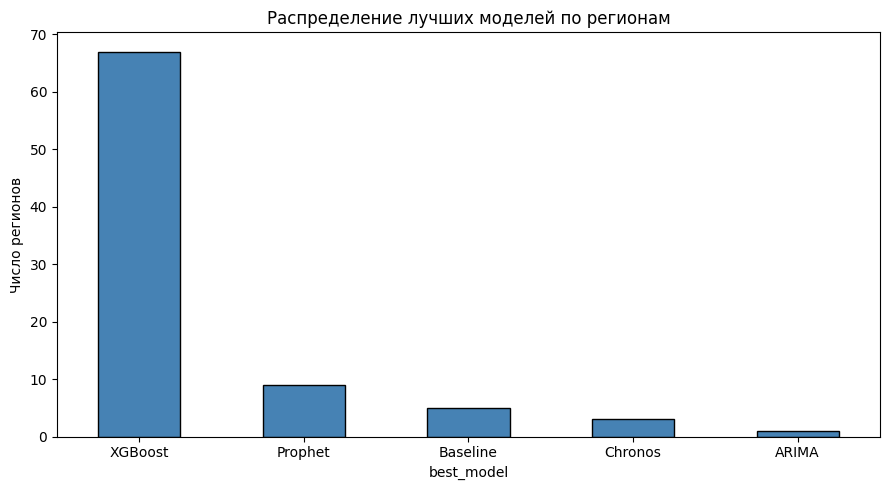

XGBoost побил Prophet в 67 из 85 регионов
Средний improvement XGBoost: 42.92%


In [12]:
best = unified["best_model"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
best.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Распределение лучших моделей по регионам")
ax.set_ylabel("Число регионов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"XGBoost побил Prophet в {(unified['best_model'] == 'XGBoost').sum()} из 85 регионов")
print(f"Средний improvement XGBoost: {unified['xgboost_improvement_vs_baseline'].mean():.2%}")

## 4. Failure cases

В 11 регионах XGBoost уступил baseline. Причины:
- **Разворот тренда:** Ингушетия, Калмыкия.
- **Сильный монотонный baseline:** Архангельская область без АО.
- **Масштаб:** Москва.
- **Пограничные случаи:** 7 регионов с improvement > −0.5.

In [13]:
failures = unified[unified["xgboost_improvement_vs_baseline"] < 0].copy()
failures = failures.sort_values("xgboost_improvement_vs_baseline")

failures[[
    "region", "best_baseline",
    "baseline_sMAPE", "xgboost_sMAPE",
    "xgboost_improvement_vs_baseline",
]].round(3)

,region,best_baseline,baseline_sMAPE,xgboost_sMAPE,xgboost_improvement_vs_baseline
48,Республика Ингушетия,MA5,6.356,22.760,-2.581
49,Республика Калмыкия,MA5,16.721,47.522,-1.842
2,Архангельская область (без автономного округа),Naive,3.854,8.736,-1.267
51,Республика Коми,MA3,8.053,11.330,-0.407
29,Москва,Naive,50.045,67.819,-0.355
8,Вологодская область,MA3,13.783,17.466,-0.267
3,Астраханская область,Naive,13.372,14.861,-0.111
32,Ненецкий автономный округ,Naive,11.485,11.838,-0.031
74,Тюменская область (без автономных округов),MA3,20.661,21.181,-0.025
78,Ханты-Мансийский автономный округ — Югра,Naive,31.914,32.261,-0.011


## 5. Change Point Detection (CPD)

Обнаружение структурных сдвигов тремя методами: CUSUM, PELT, Binseg. Консенсус — если ≥ 2 метода нашли точку в пределах ±1 год.

In [14]:
qa_text = open("../reports/cpd_qa.txt", encoding="utf-8").read()
print(qa_text)

CPD QUALITY ASSURANCE
Duplicate rows: 0
Invalid years: 0
Total detections: 577
Consensus points: 189
3/3 consensus: 47
Regions with 3/3: 45



## 6. Связь CPD и качества прогноза

После tolerance=1 CPD есть у всех 85 регионов. Делим по силе сигнала относительно медианы (1.4715). Mann-Whitney U test проверяет, отличается ли sMAPE XGBoost между регионами с сильным и слабым сигналом CPD.

In [15]:
from scipy import stats

median_signal = unified["cpd_max_signal"].median()

strong = unified[unified["cpd_max_signal"] > median_signal]["xgboost_sMAPE"].dropna()
weak = unified[unified["cpd_max_signal"] <= median_signal]["xgboost_sMAPE"].dropna()

stat, p_val = stats.mannwhitneyu(strong, weak, alternative="two-sided")

print(f"Медиана cpd_max_signal: {median_signal:.4f}")
print(f"Strong CPD: n={len(strong)}, mean={strong.mean():.2f}%, median={strong.median():.2f}%")
print(f"Weak CPD:   n={len(weak)}, mean={weak.mean():.2f}%, median={weak.median():.2f}%")
print(f"Mann-Whitney U: stat={stat:.2f}, p-value={p_val:.4f}")

if p_val > 0.05:
    print("→ Разница статистически НЕЗНАЧИМА.")

Медиана cpd_max_signal: 1.4715
Strong CPD: n=42, mean=15.82%, median=11.78%
Weak CPD:   n=43, mean=15.82%, median=13.79%
Mann-Whitney U: stat=778.00, p-value=0.2738
→ Разница статистически НЕЗНАЧИМА.


## 7. Финальные графики

Смотрим визуализации из `reports/figures/`.


final_best_model_distribution.png


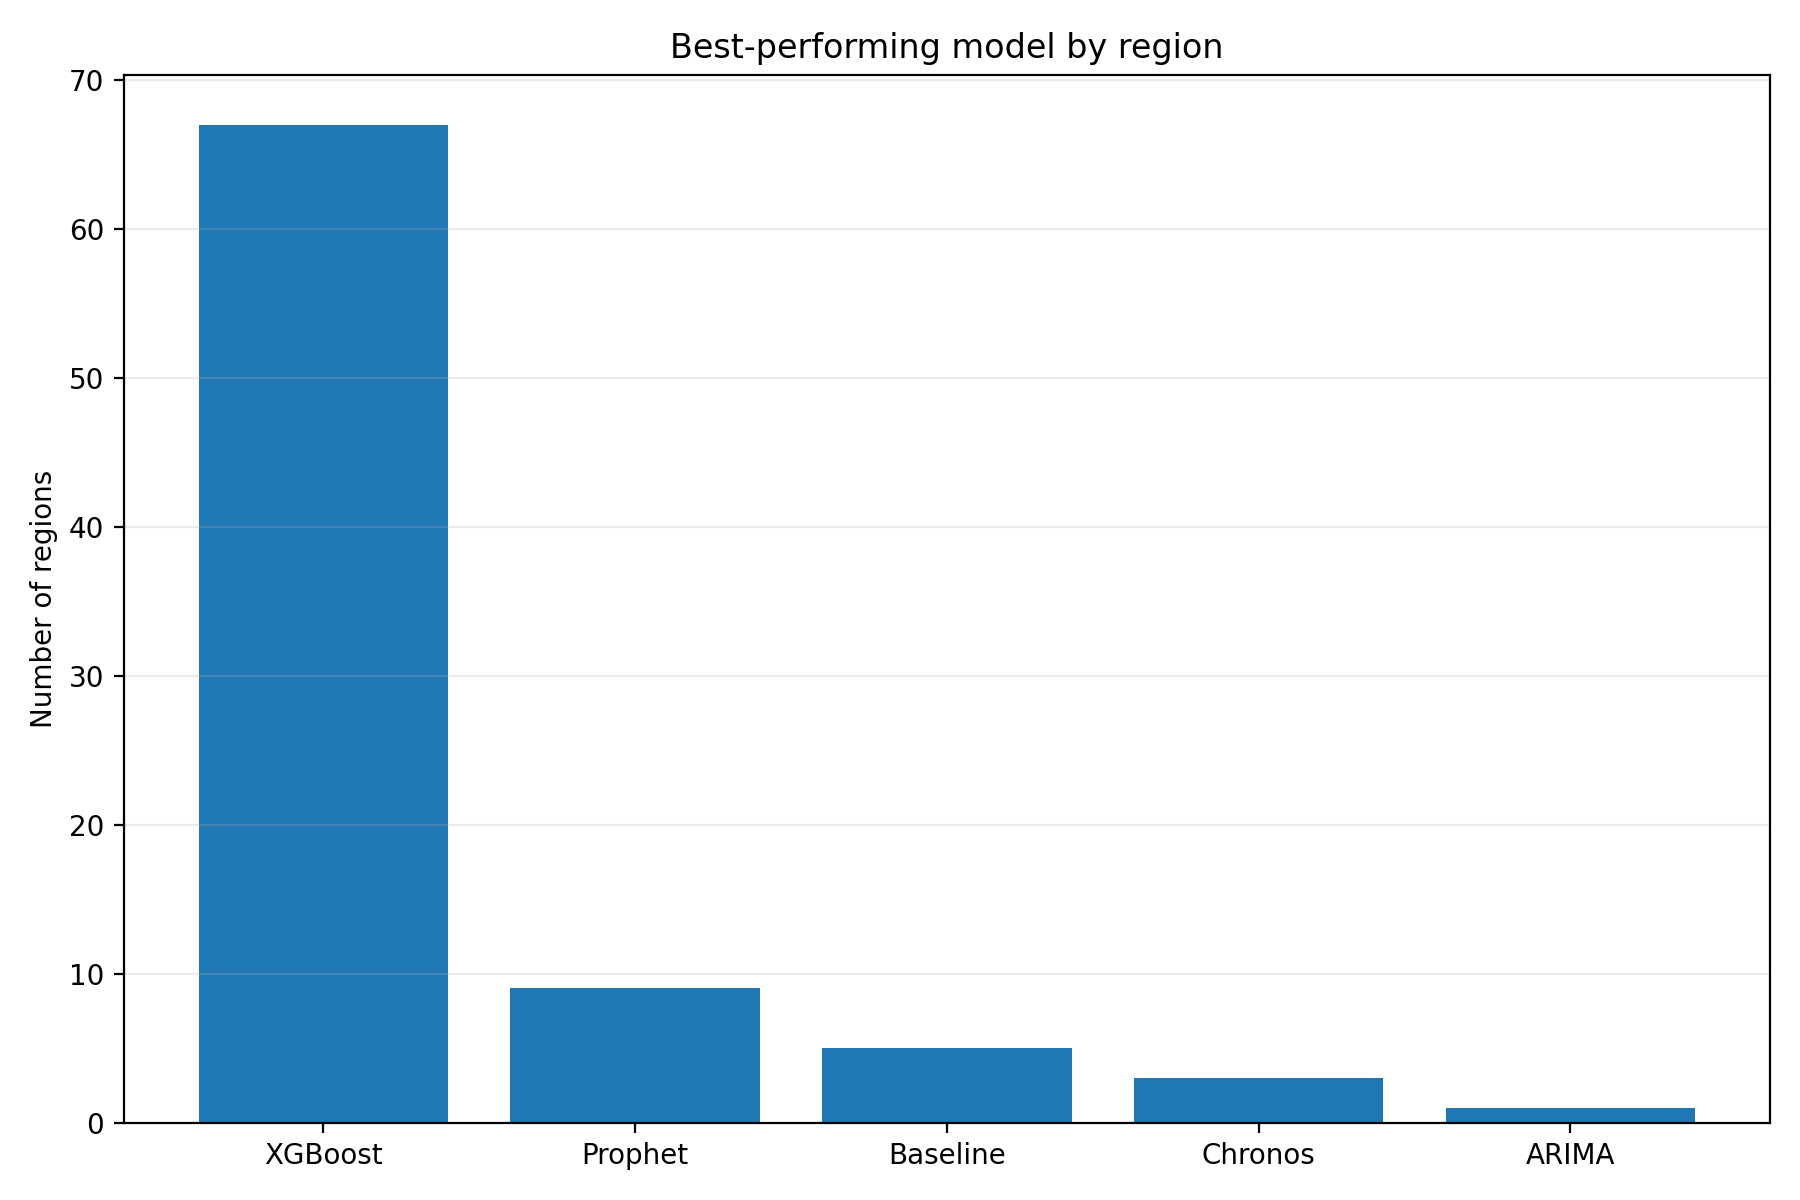


final_cpd_years.png


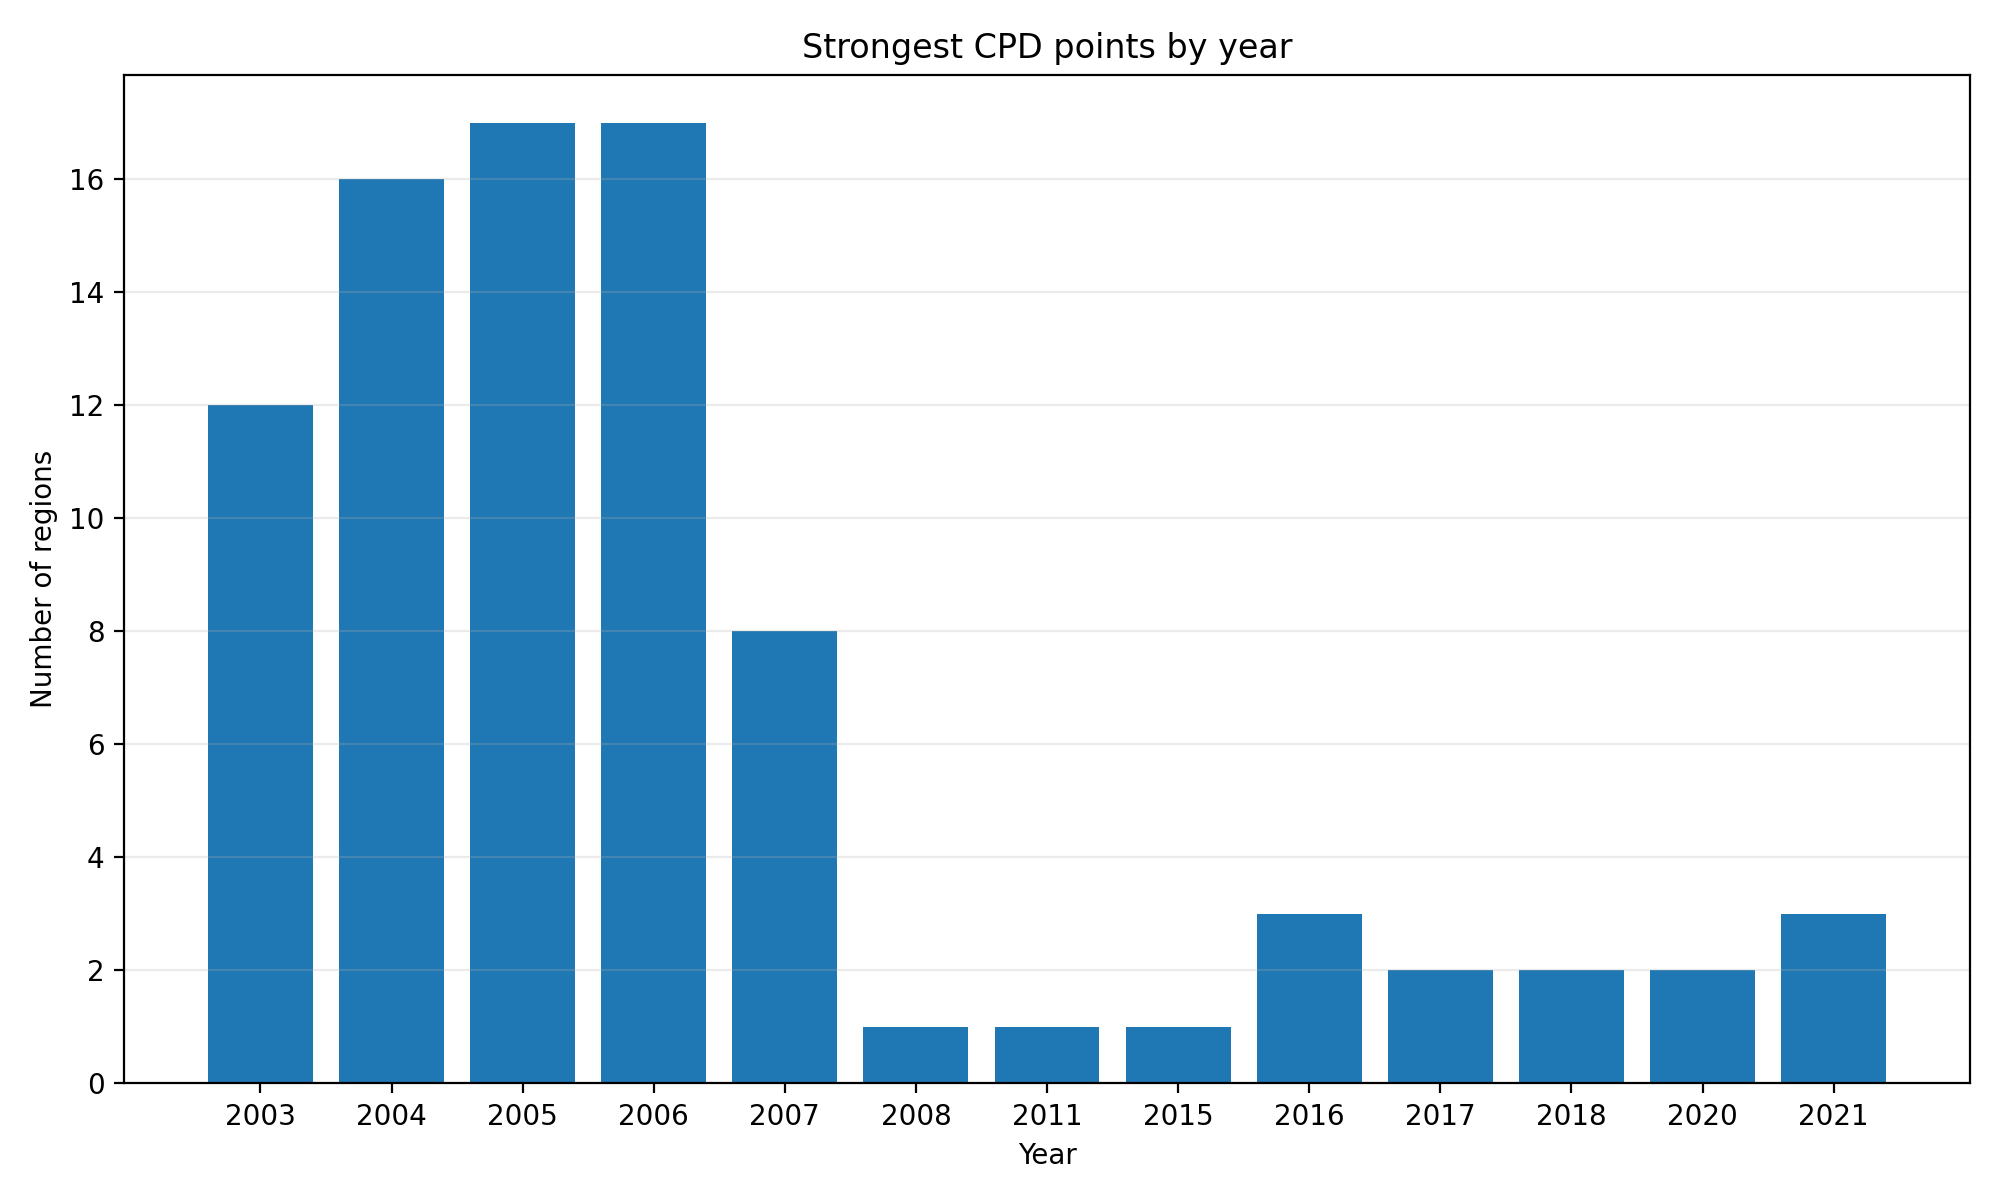


final_model_comparison.png


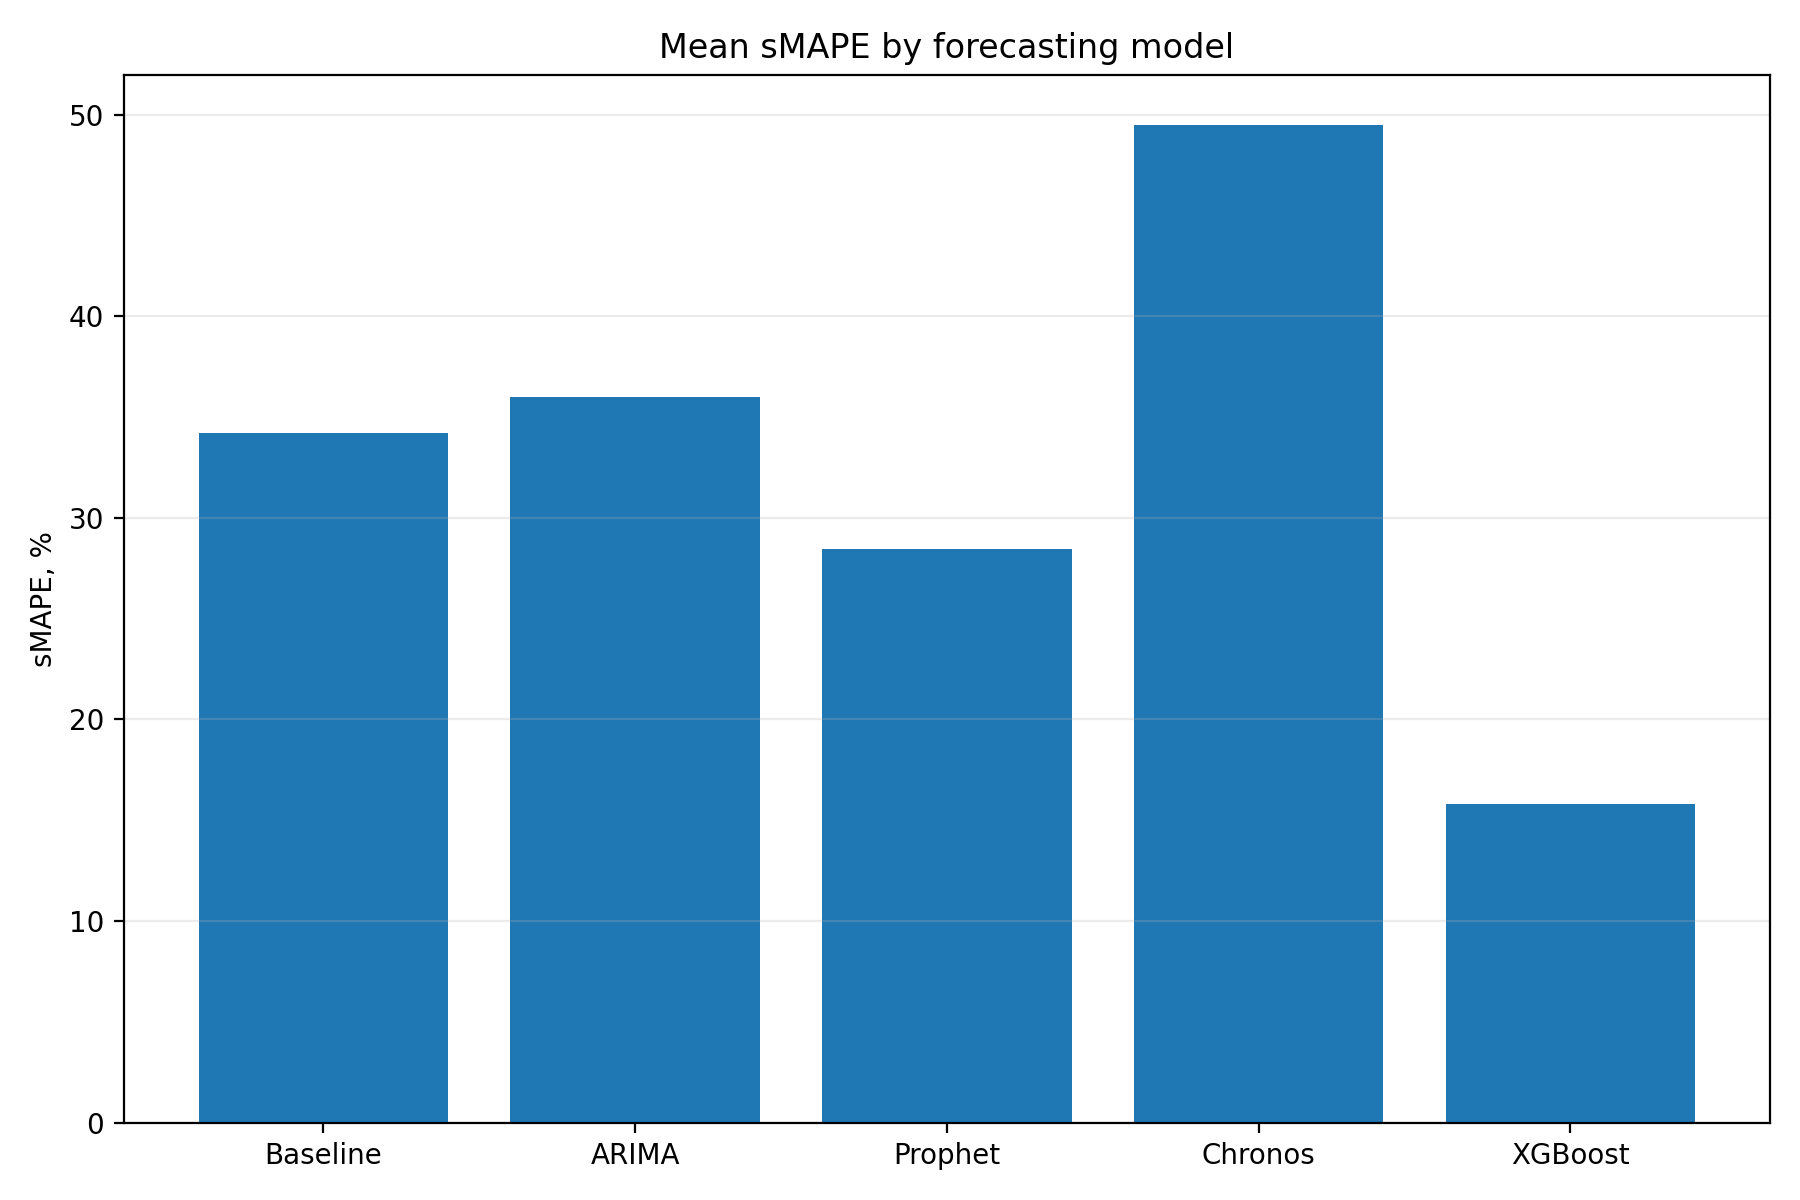


final_xgboost_improvement_distribution.png


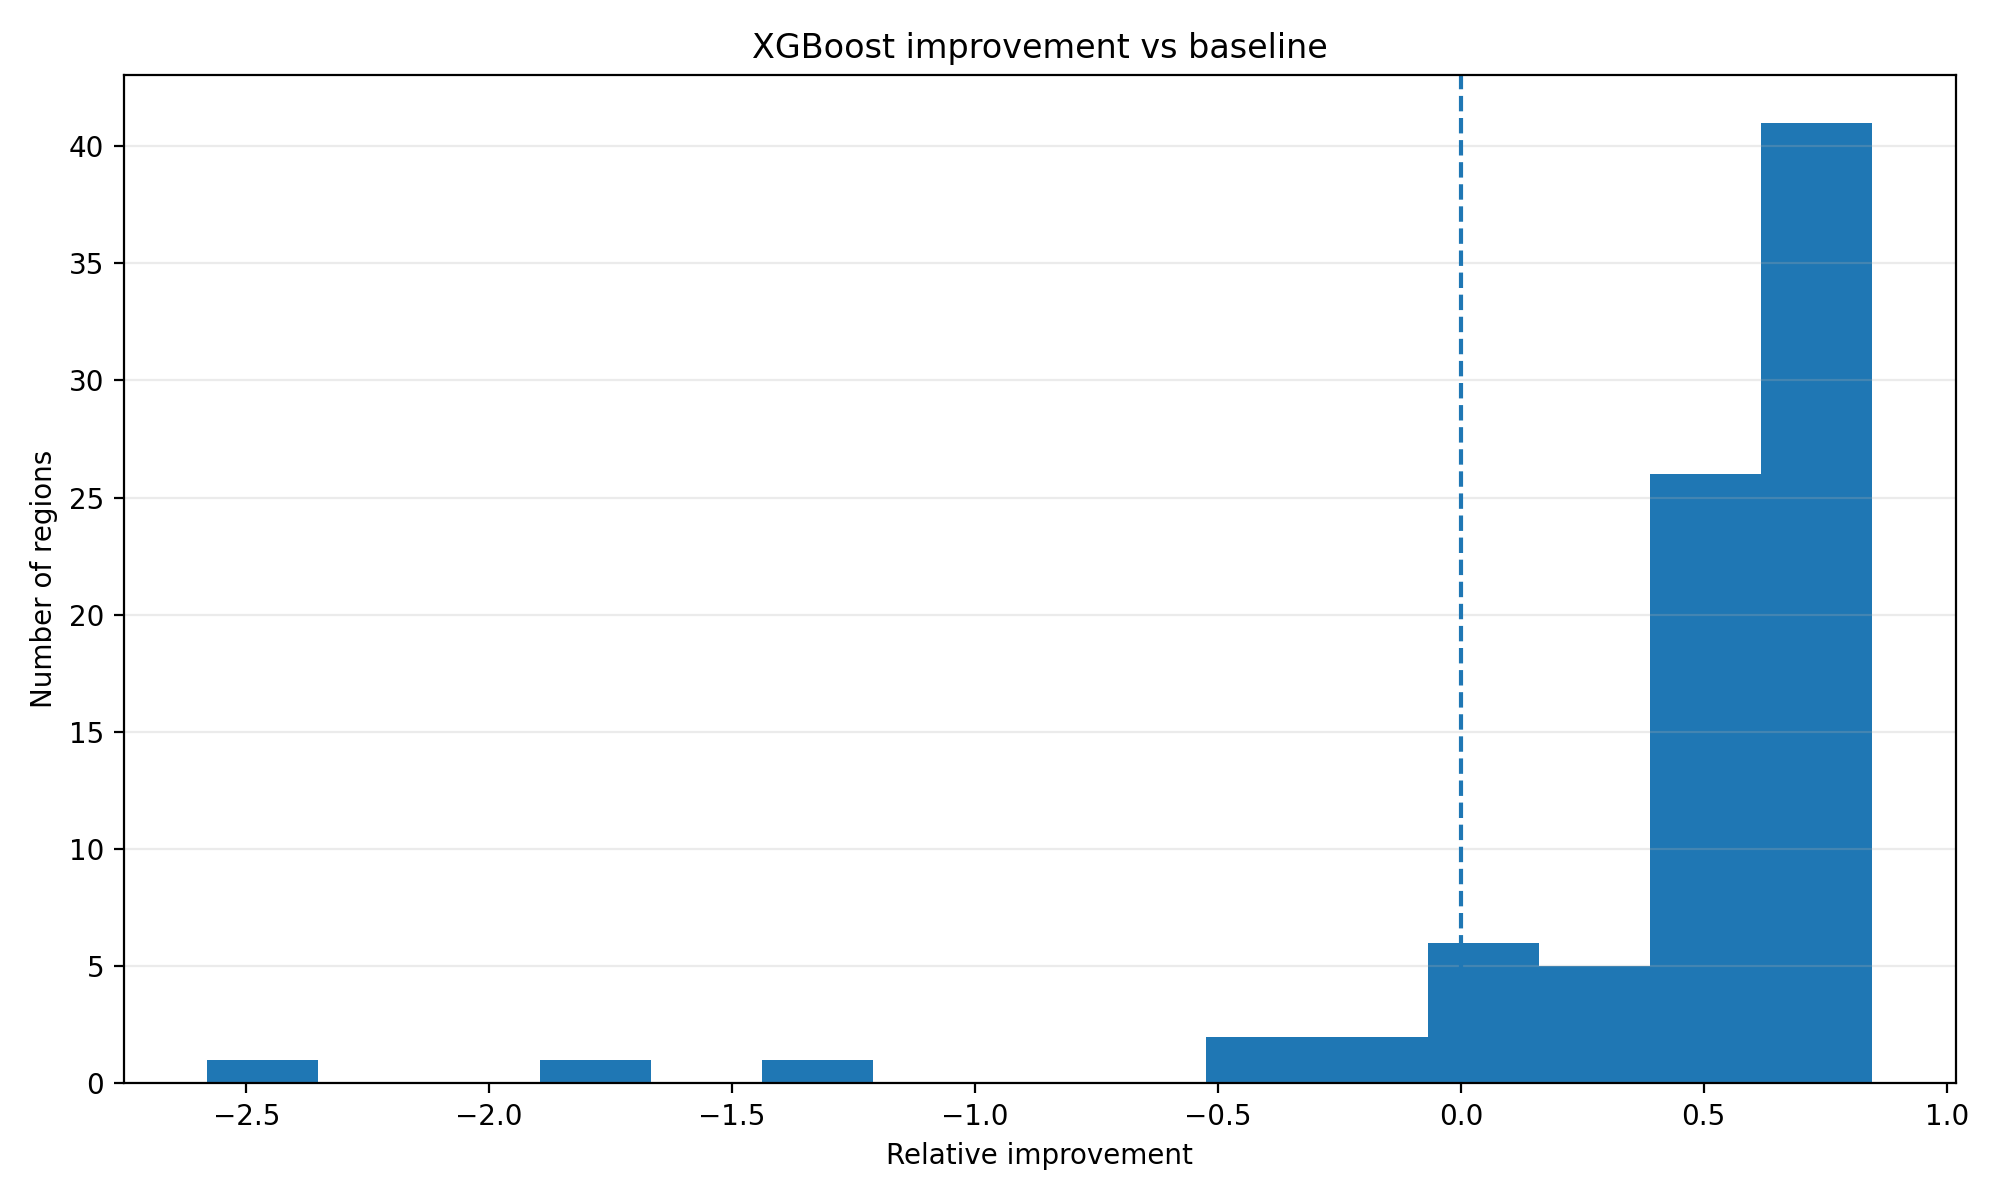

In [17]:
from IPython.display import Image, display
from pathlib import Path

figures = sorted(Path("../reports/figures").glob("final_*.png"))
for fig in figures:
    print(f"\n{fig.name}")
    display(Image(filename=str(fig)))

## 8. Ограничения

- Короткие ряды (23 наблюдения на регион).
- Внешние признаки дают < 30% важности XGBoost.
- Масштаб Москвы создаёт сложности при обучении.
- Годовая частота: горизонты 1, 3, 6 месяцев недоступны.
- Новостные данные не интегрированы.

## 9. Выводы

1. **XGBoost — лучшая модель прогнозирования.** sMAPE 15.82% против 28.44% у Prophet. Превосходит Prophet в 79% регионов.
2. **CPD даёт устойчивые результаты.** 189 консенсусных точек, 47 с 3/3 консенсусом в 45 регионах.
3. **Связь CPD и прогноза не подтверждена статистически.** p = 0.075.
4. **Методология воспроизводима.** Все скрипты запускаются из корня проекта, конфиги — в YAML.